In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
    
df_merge_2 = pd.read_csv('data_tmp/series_data_2026-06-14.csv')

df_merge_2["EmissionDate"] = pd.to_datetime(df_merge_2["EmissionDate"])
df_merge_2["MaturityDate"] = pd.to_datetime(df_merge_2["MaturityDate"])
df_merge_2.head()

,country,EmissionDate,Interest,bond,MaturityDate,IPC_end,IPC_start,accumulatedInflation,Currency,ExchangeRate_start,ExchangeRate_end,rentability
0,indonesia,2022-07-19,0.02510,Indonesia 1M,2022-08-19,27.112849,26.926047,0.006938,IDR,14987.692383,4.00,3813.507446
1,indonesia,2022-05-19,0.02190,Indonesia 3M,2022-08-19,27.112849,26.063553,0.040259,IDR,15366.000000,4.00,3772.702874
2,indonesia,2021-08-19,0.03064,Indonesia 1Y,2022-08-19,27.112849,22.475825,0.206312,IDR,16603.574219,4.00,3545.411211
3,indonesia,2015-08-05,0.07796,Indonesia 1Y,2016-08-05,20.986715,21.217691,-0.010886,IDR,14770.000000,14.56,1104.542444
4,indonesia,2016-02-05,0.05900,Indonesia 6M,2016-08-05,20.986715,20.639262,0.016835,IDR,15265.000000,14.56,1090.895504


In [19]:
df_indonesia = df_merge_2[df_merge_2['country'] == 'indonesia']
df_indonesia = df_indonesia.sort_values("EmissionDate")

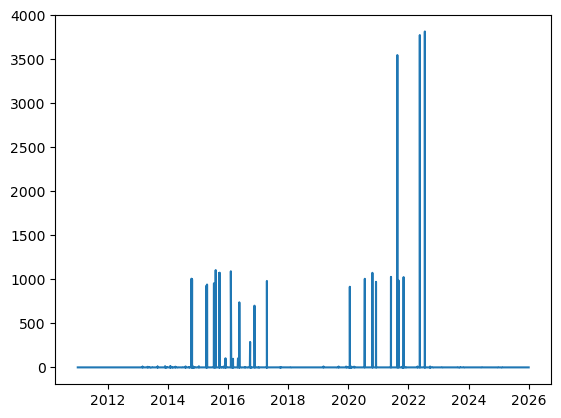

In [20]:
plt.plot(df_indonesia['EmissionDate'], df_indonesia['rentability'])
plt.show()

Creo que la explicacion de la rentabilidad en estos casos se debe a combinaciones espcíficas entre un interés alto, un momentop de deflación y una diferencia entre los tipos de cambio de emisión y recepción muy ventajosas

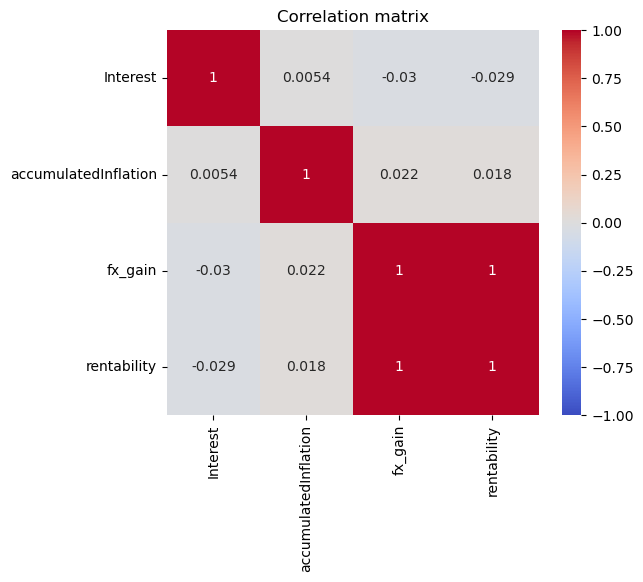

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df_indonesia.copy()
df_corr["fx_gain"] = (
    df_corr["ExchangeRate_start"]
    / df_corr["ExchangeRate_end"]
    - 1
)

df_corr = df_corr[['Interest','accumulatedInflation', "fx_gain", "rentability"]]


corr = df_corr.corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,      
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation matrix")
plt.show()

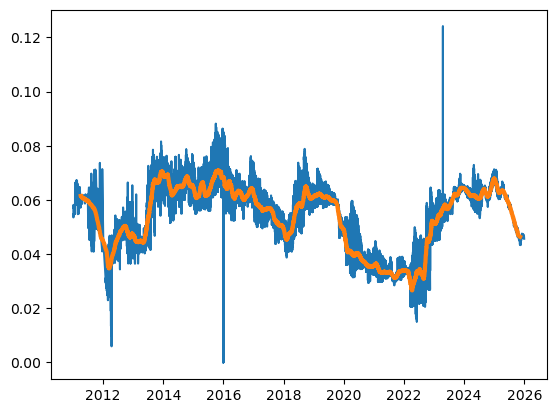

In [37]:
df_plot = df_indonesia.sort_values("EmissionDate")

rolling = (
    df_plot["Interest"]
    .rolling(window=90, center=True)
    .mean()
)

plt.plot(df_plot["EmissionDate"], df_plot["Interest"])
plt.plot(df_plot["EmissionDate"], rolling, linewidth=3)

plt.show()

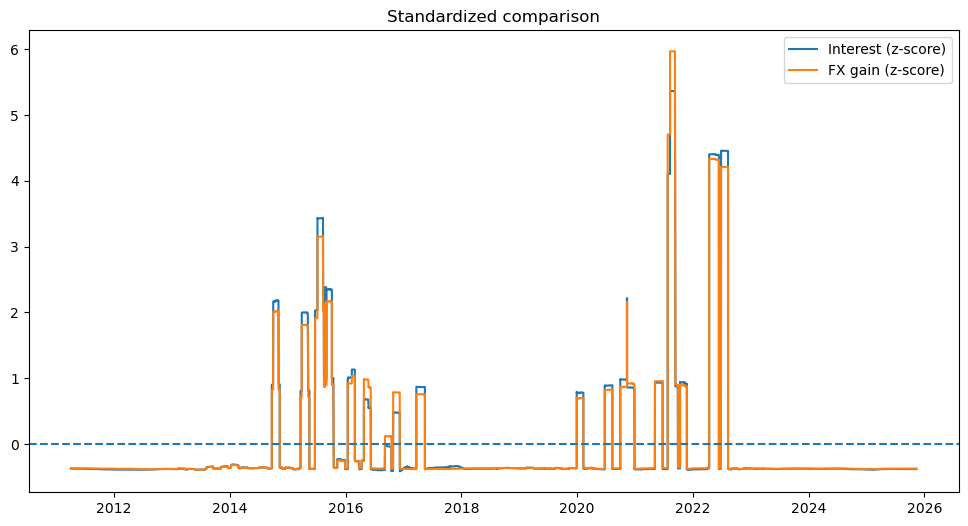

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Ordenar por fecha de emisión
df_plot = df_indonesia.sort_values("EmissionDate").copy()

# Componente cambiario coherente con la fórmula de rentabilidad
df_plot["fx_gain"] = (
    df_plot["ExchangeRate_start"]
    / df_plot["ExchangeRate_end"]
    - 1
)

# Suavizado temporal
interest_roll = (
    df_plot["rentability"]
    .rolling(window=90, center=True)
    .mean()
)

fx_roll = (
    df_plot["fx_gain"]
    .rolling(window=90, center=True)
    .mean()
)

# Dataset para comparar
tmp = pd.DataFrame({
    "date": df_plot["EmissionDate"],
    "interest": interest_roll,
    "fx_gain": fx_roll
}).dropna()


scaler = StandardScaler()

tmp[["rentability", "fx_z"]] = scaler.fit_transform(
    tmp[["interest", "fx_gain"]]
)

plt.figure(figsize=(12,6))

plt.plot(
    tmp["date"],
    tmp["rentability"],
    label="Interest (z-score)"
)

plt.plot(
    tmp["date"],
    tmp["fx_z"],
    label="FX gain (z-score)"
)

plt.axhline(0, linestyle="--")

plt.legend()
plt.title("Standardized comparison")
plt.show()

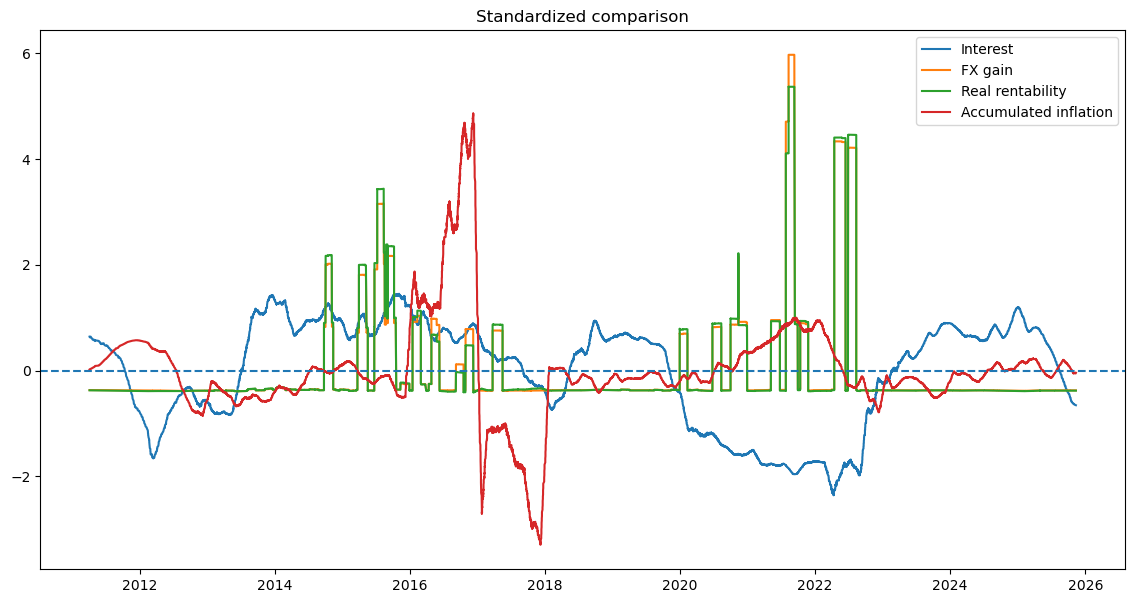

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Ordenar por fecha
df_plot = df_indonesia.sort_values("EmissionDate").copy()

# Componente cambiario
df_plot["fx_gain"] = (
    df_plot["ExchangeRate_start"]
    / df_plot["ExchangeRate_end"]
    - 1
)

# Suavizados
interest_roll = (
    df_plot["Interest"]
    .rolling(window=90, center=True)
    .mean()
)

fx_roll = (
    df_plot["fx_gain"]
    .rolling(window=90, center=True)
    .mean()
)

rentability_roll = (
    df_plot["rentability"]
    .rolling(window=90, center=True)
    .mean()
)

inflation_roll = (
    df_plot["accumulatedInflation"]
    .rolling(window=90, center=True)
    .mean()
)

# Dataset conjunto
tmp = pd.DataFrame({
    "date": df_plot["EmissionDate"],
    "interest": interest_roll,
    "fx_gain": fx_roll,
    "rentability": rentability_roll,
    "inflation": inflation_roll
}).dropna()

# Estandarización
scaler = StandardScaler()

tmp[[
    "interest_z",
    "fx_z",
    "rentability_z",
    "inflation_z"
]] = scaler.fit_transform(
    tmp[[
        "interest",
        "fx_gain",
        "rentability",
        "inflation"
    ]]
)

# Gráfico
plt.figure(figsize=(14,7))

plt.plot(
    tmp["date"],
    tmp["interest_z"],
    label="Interest"
)

plt.plot(
    tmp["date"],
    tmp["fx_z"],
    label="FX gain"
)

plt.plot(
    tmp["date"],
    tmp["rentability_z"],
    label="Real rentability"
)

plt.plot(
    tmp["date"],
    tmp["inflation_z"],
    label="Accumulated inflation"
)

plt.axhline(0, linestyle="--")

plt.legend()
plt.title("Standardized comparison")
plt.show()

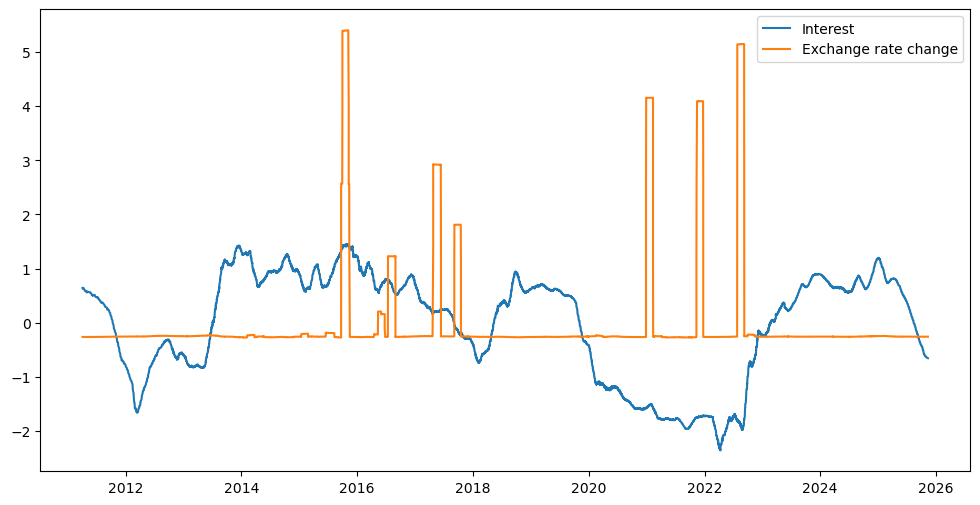

In [53]:
from sklearn.preprocessing import StandardScaler

# Tendencias suavizadas
interest_roll = (
    df_plot["Interest"]
    .rolling(window=90, center=True)
    .mean()
)

exch_roll = (
    (
    (df_plot["ExchangeRate_end"]
     - df_plot["ExchangeRate_start"])
    / df_plot["ExchangeRate_start"]
)
    .rolling(window=90, center=True)
    .mean()
)

# Eliminar NaNs generados por rolling
tmp = pd.DataFrame({
    "date": df_plot["EmissionDate"],
    "interest": interest_roll,
    "exch": exch_roll
}).dropna()

scaler = StandardScaler()

tmp[["interest_z", "exch_z"]] = scaler.fit_transform(
    tmp[["interest", "exch"]]
)

plt.figure(figsize=(12,6))
plt.plot(tmp["date"], tmp["interest_z"], label="Interest")
plt.plot(tmp["date"], tmp["exch_z"], label="Exchange rate change")
plt.legend()
plt.show()

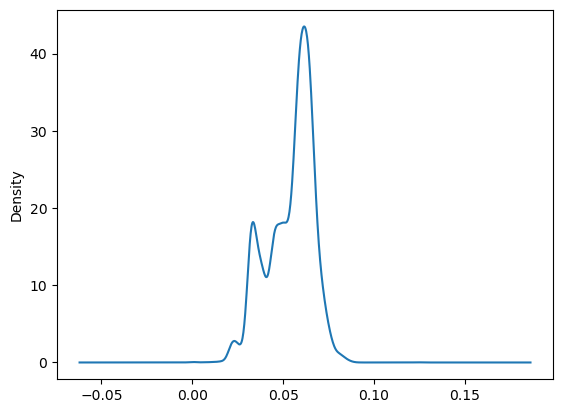

In [6]:
df_indonesia["Interest"].plot.kde()
plt.show()

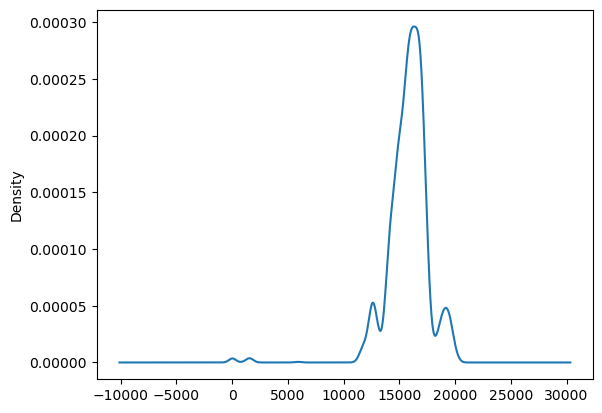

In [8]:
df_indonesia["ExchangeRate_end"].plot.kde()
plt.show()